# Experiment 2: Housing Price Prediction

**Objective**: Predict housing prices using:
- a. Deep Feed Forward Network
- b. Simple Linear Regression

**Dataset**: California Housing Dataset (scikit-learn)

## 1. Import Libraries

In [ ]:
pip install seaborn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 2. Load and Explore Dataset

In [2]:
# Load California Housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

# Create DataFrame for exploration
df = pd.DataFrame(X, columns=housing.feature_names)
df['Price'] = y

print("Dataset Shape:", X.shape)
print("\nFeature Names:", housing.feature_names)
print("\nDataset Description:")
print(housing.DESCR[:1000])

Dataset Shape: (20640, 8)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Dataset Description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house 

In [3]:
# Display first few rows
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Statistical summary
print("\nStatistical Summary:")
df.describe()


Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [5]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64


## 3. Data Preprocessing

In [6]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 16512
Test samples: 4128


In [7]:
# Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied.")
print(f"Scaled Training Data - Mean: {X_train_scaled.mean(axis=0).round(4)}")
print(f"Scaled Training Data - Std: {X_train_scaled.std(axis=0).round(4)}")

Feature scaling applied.
Scaled Training Data - Mean: [-0. -0.  0. -0. -0. -0.  0. -0.]
Scaled Training Data - Std: [1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Data Visualization

FileNotFoundError: [Errno 2] No such file or directory: '../data/housing_eda.png'

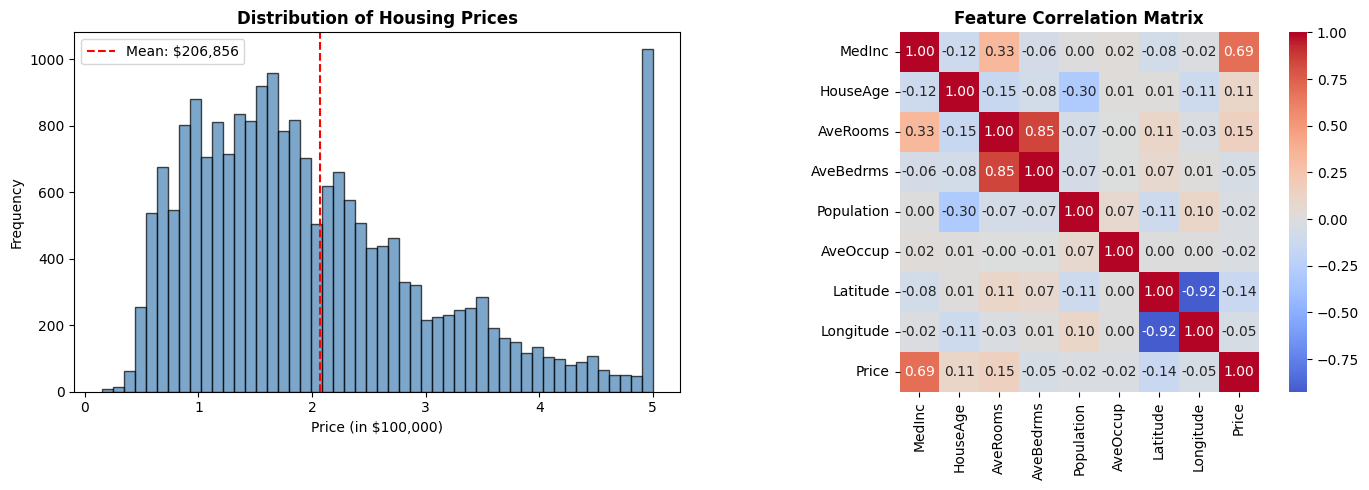

In [8]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Price (in $100,000)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Housing Prices', fontweight='bold')
axes[0].axvline(y.mean(), color='red', linestyle='--', label=f'Mean: ${y.mean()*100000:,.0f}')
axes[0].legend()

# Correlation heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', ax=axes[1], square=True)
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('../data/housing_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 5a. Simple Linear Regression

In [9]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Evaluate
lr_metrics = {
    'train_mse': mean_squared_error(y_train, y_pred_lr_train),
    'test_mse': mean_squared_error(y_test, y_pred_lr_test),
    'train_mae': mean_absolute_error(y_train, y_pred_lr_train),
    'test_mae': mean_absolute_error(y_test, y_pred_lr_test),
    'train_r2': r2_score(y_train, y_pred_lr_train),
    'test_r2': r2_score(y_test, y_pred_lr_test)
}

print("Linear Regression Results:")
print("="*40)
print(f"Training MSE: {lr_metrics['train_mse']:.4f}")
print(f"Test MSE: {lr_metrics['test_mse']:.4f}")
print(f"Training MAE: {lr_metrics['train_mae']:.4f}")
print(f"Test MAE: {lr_metrics['test_mae']:.4f}")
print(f"Training R²: {lr_metrics['train_r2']:.4f}")
print(f"Test R²: {lr_metrics['test_r2']:.4f}")

Linear Regression Results:
Training MSE: 0.5179
Test MSE: 0.5559
Training MAE: 0.5286
Test MAE: 0.5332
Training R²: 0.6126
Test R²: 0.5758


In [10]:
# Linear Regression coefficients
print("\nFeature Coefficients:")
for name, coef in zip(housing.feature_names, lr_model.coef_):
    print(f"  {name}: {coef:.4f}")
print(f"\nIntercept: {lr_model.intercept_:.4f}")


Feature Coefficients:
  MedInc: 0.8544
  HouseAge: 0.1225
  AveRooms: -0.2944
  AveBedrms: 0.3393
  Population: -0.0023
  AveOccup: -0.0408
  Latitude: -0.8969
  Longitude: -0.8698

Intercept: 2.0719


## 5b. Deep Feed Forward Network

In [11]:
# Build Deep Feed Forward Network
def build_dnn_model(input_shape):
    model = keras.Sequential([
        layers.Input(shape=(input_shape,)),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)  # Output layer for regression
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )
    return model

# Create model
dnn_model = build_dnn_model(X_train_scaled.shape[1])
dnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,481 (48.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [12]:
# Train DNN model
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

history = dnn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 1.6612 - mae: 0.9420 - val_loss: 0.5335 - val_mae: 0.5418
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.5311 - mae: 0.5361 - val_loss: 0.4207 - val_mae: 0.4695
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4576 - mae: 0.4932 - val_loss: 0.4156 - val_mae: 0.4729
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4204 - mae: 0.4683 - val_loss: 0.3866 - val_mae: 0.4476
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4014 - mae: 0.4552 - val_loss: 0.3759 - val_mae: 0.4424
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3852 - mae: 0.4461 - val_loss: 0.3739 - val_mae: 0.4425
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3758 - mae: 0.4376 - val_loss: 0.3734 - val_mae: 0.4416
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3701 - mae: 0.4348 - val_loss: 0.3653 - val_mae: 0.4355
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

In [13]:
# Evaluate DNN model
y_pred_dnn_train = dnn_model.predict(X_train_scaled, verbose=0).flatten()
y_pred_dnn_test = dnn_model.predict(X_test_scaled, verbose=0).flatten()

dnn_metrics = {
    'train_mse': mean_squared_error(y_train, y_pred_dnn_train),
    'test_mse': mean_squared_error(y_test, y_pred_dnn_test),
    'train_mae': mean_absolute_error(y_train, y_pred_dnn_train),
    'test_mae': mean_absolute_error(y_test, y_pred_dnn_test),
    'train_r2': r2_score(y_train, y_pred_dnn_train),
    'test_r2': r2_score(y_test, y_pred_dnn_test)
}

print("\nDeep Feed Forward Network Results:")
print("="*40)
print(f"Training MSE: {dnn_metrics['train_mse']:.4f}")
print(f"Test MSE: {dnn_metrics['test_mse']:.4f}")
print(f"Training MAE: {dnn_metrics['train_mae']:.4f}")
print(f"Test MAE: {dnn_metrics['test_mae']:.4f}")
print(f"Training R²: {dnn_metrics['train_r2']:.4f}")
print(f"Test R²: {dnn_metrics['test_r2']:.4f}")


Deep Feed Forward Network Results:
Training MSE: 0.2886
Test MSE: 0.3108
Training MAE: 0.3822
Test MAE: 0.3932
Training R²: 0.7841
Test R²: 0.7628


## 6. Training History Visualization

FileNotFoundError: [Errno 2] No such file or directory: '../data/housing_training_history.png'

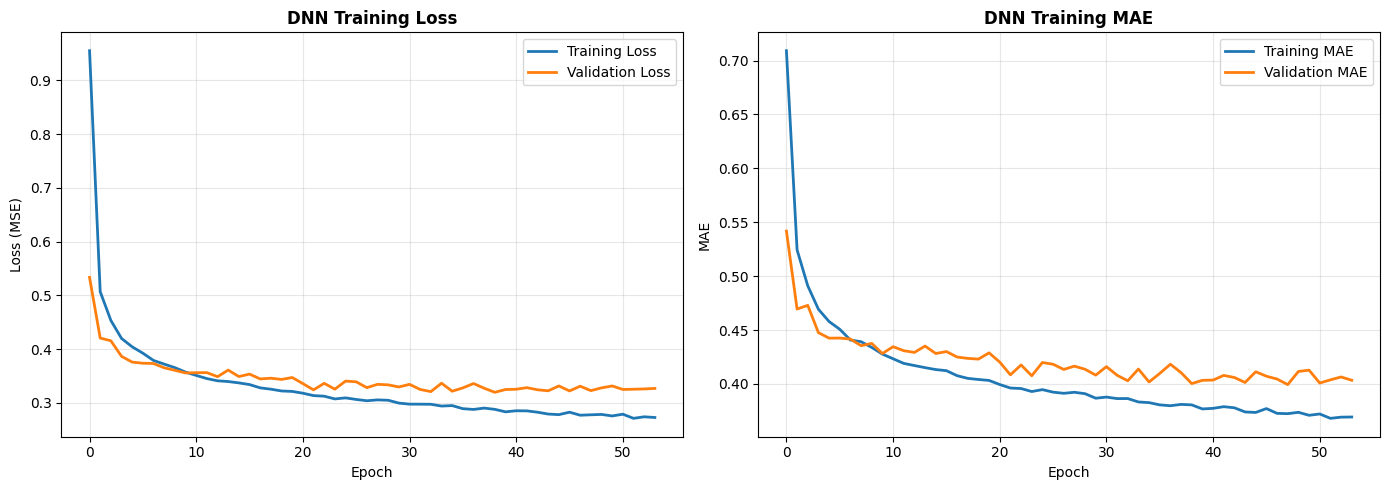

In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('DNN Training Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history.history['mae'], label='Training MAE', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('DNN Training MAE', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/housing_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Model Comparison

FileNotFoundError: [Errno 2] No such file or directory: '../data/housing_predictions.png'

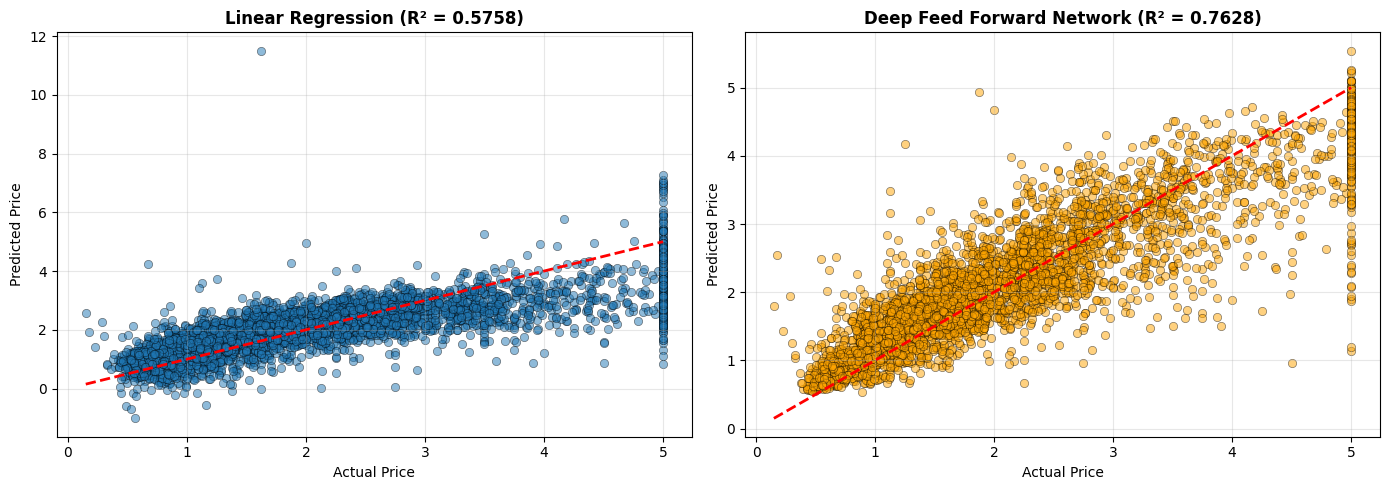

In [15]:
# Compare predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression predictions
axes[0].scatter(y_test, y_pred_lr_test, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Linear Regression (R² = {lr_metrics["test_r2"]:.4f})', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# DNN predictions
axes[1].scatter(y_test, y_pred_dnn_test, alpha=0.5, edgecolors='k', linewidth=0.5, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Deep Feed Forward Network (R² = {dnn_metrics["test_r2"]:.4f})', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/housing_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Summary comparison
comparison_df = pd.DataFrame({
    'Metric': ['MSE (Train)', 'MSE (Test)', 'MAE (Train)', 'MAE (Test)', 'R² (Train)', 'R² (Test)'],
    'Linear Regression': [
        lr_metrics['train_mse'], lr_metrics['test_mse'],
        lr_metrics['train_mae'], lr_metrics['test_mae'],
        lr_metrics['train_r2'], lr_metrics['test_r2']
    ],
    'Deep FeedForward Network': [
        dnn_metrics['train_mse'], dnn_metrics['test_mse'],
        dnn_metrics['train_mae'], dnn_metrics['test_mae'],
        dnn_metrics['train_r2'], dnn_metrics['test_r2']
    ]
})

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(comparison_df.to_string(index=False))


MODEL COMPARISON SUMMARY
     Metric  Linear Regression  Deep FeedForward Network
MSE (Train)           0.517933                  0.288557
 MSE (Test)           0.555892                  0.310847
MAE (Train)           0.528628                  0.382177
 MAE (Test)           0.533200                  0.393192
 R² (Train)           0.612551                  0.784140
  R² (Test)           0.575788                  0.762786


## 8. Conclusion

In [17]:
print("\n" + "="*60)
print("EXPERIMENT 2 SUMMARY: Housing Price Prediction")
print("="*60)

winner = "Deep Feed Forward Network" if dnn_metrics['test_r2'] > lr_metrics['test_r2'] else "Linear Regression"
improvement = abs(dnn_metrics['test_r2'] - lr_metrics['test_r2']) * 100

print(f"\nBest Model: {winner}")
print(f"R² Improvement: {improvement:.2f}%")

print("\nKey Observations:")
print("- Linear Regression: Simple, interpretable, fast training")
print("- DNN: Can capture non-linear relationships, requires more data")
print("- Both models benefit from feature scaling (StandardScaler)")
print("- DNN uses dropout and batch normalization to prevent overfitting")


EXPERIMENT 2 SUMMARY: Housing Price Prediction

Best Model: Deep Feed Forward Network
R² Improvement: 18.70%

Key Observations:
- Linear Regression: Simple, interpretable, fast training
- DNN: Can capture non-linear relationships, requires more data
- Both models benefit from feature scaling (StandardScaler)
- DNN uses dropout and batch normalization to prevent overfitting
